# Online Retail Dataset Analysis

## Introduction

The **Online Retail** dataset contains transaction records from a UK-based online retail store. It includes detailed information about customer purchases, such as invoice numbers, product descriptions, quantities, unit prices, purchase dates, customer identifiers, and countries.

This dataset provides valuable insights into customer purchasing behavior, product demand, and sales performance over time. Due to its transactional nature, it is well suited for data cleaning, feature engineering, exploratory data analysis (EDA), and business intelligence applications.

In this project, the dataset will be explored to assess its quality, cleaned to resolve data issues, enhanced through feature engineering, and analyzed to uncover meaningful business insights that can support data-driven decision making.


In [101]:
import pandas as pd

#load retail dataset
df = pd.read_csv("online_retail.csv")

#display a sample of it
display(df.sample(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
495961,578344,21090,SET/6 COLLAGE PAPER PLATES,1,2011-11-24 09:21:00,0.83,NaN,United Kingdom
136664,547967,84596B,SMALL DOLLY MIX DESIGN ORANGE BOWL,1,2011-03-28 15:49:00,0.83,NaN,United Kingdom
218147,556019,23173,REGENCY TEAPOT ROSES,12,2011-06-08 12:02:00,8.15,18092.0,United Kingdom
366874,568798,23189,SET OF 12 FORK CANDLES,12,2011-09-29 10:23:00,2.89,12615.0,France
312699,564366,23169,CLASSIC GLASS COOKIE JAR,6,2011-08-25 08:58:00,4.15,13236.0,United Kingdom
501947,578833,22734,SET OF 6 RIBBONS VINTAGE CHRISTMAS,13,2011-11-25 15:23:00,5.79,NaN,United Kingdom
167465,550988,22905,CALENDAR IN SEASON DESIGN,6,2011-04-21 18:10:00,2.95,14231.0,United Kingdom
230769,557217,22489,PACK OF 12 TRADITIONAL CRAYONS,24,2011-06-17 12:30:00,0.42,17426.0,United Kingdom
169957,551270,21287,SCENTED VELVET LOUNGE CANDLE,12,2011-04-27 12:35:00,1.25,15891.0,United Kingdom
310760,564199,22667,RECIPE BOX RETROSPOT,1,2011-08-23 17:31:00,2.95,13263.0,United Kingdom


In [102]:
# display the columns
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [103]:
df.shape

(541909, 8)

In [104]:
# observe useful insights
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [105]:
# ckeck for datatypes and observe the data metadata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [106]:
# check for null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [107]:
# check for duplicated values
df.duplicated().sum()

np.int64(5268)

In [108]:
# Countries in the dataset
df["Country"].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [109]:
# Check for negative quantities
(df["Quantity"] <= 0).sum()


np.int64(10624)

In [110]:
# Check for zero or negative prices
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [111]:
# Number of unique customers
df["CustomerID"].nunique()

4372

In [112]:
# Number of unique products
df["StockCode"].nunique()

4070

# Data Cleaning Plan

The dataset exploration revealed several data quality issues that should be addressed before feature engineering and analysis.

### Data Quality Issues

- Duplicate transaction records are present and will be removed.
- The **CustomerID** column contains a large number of missing values and requires an appropriate handling strategy.
- A small number of missing values exist in the **Description** column and will be reviewed before analysis.
- The **InvoiceDate** column is currently stored as a text (`object`) data type and will be converted to a datetime format.
- The dataset contains negative quantities and non-positive unit prices, which require further investigation before deciding whether they represent returns, cancellations, or invalid transactions.
- Extreme numerical values will be reviewed to ensure the dataset accurately represents retail sales.

### Cleaning Objectives

The cleaning process will include:

- Removing duplicate records.
- Handling missing values appropriately.
- Converting the invoice date to a datetime format.
- Investigating and treating invalid or inconsistent numerical values.
- Validating the cleaned dataset before feature engineering.

In [113]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Handle missing values
# Remove rows with missing product descriptions
df.dropna(subset=["Description"], inplace=True)

# Remove rows with missing customer IDs
df.dropna(subset=["CustomerID"], inplace=True)

# Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Keep only completed sales
# Remove transactions with non-positive prices
df = df[df["UnitPrice"] > 0]

# Remove transactions with non-positive quantities
df = df[df["Quantity"] > 0]

# Remove leading and trailing spaces from text columns
df["Description"] = df["Description"].str.strip().str.title()
df["Country"] = df["Country"].str.strip().str.title()

# Verify the cleaning process
print(df.isnull().sum())
print(df.duplicated().sum())
df.info()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [114]:
display(df.sample(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
261384,559836,84792,Enchanted Bird Coathanger 5 Hook,4,2011-07-13 10:09:00,4.65,13911.0,United Kingdom
468572,576514,22690,Doormat Home Sweet Home Blue,2,2011-11-15 12:13:00,8.25,13950.0,United Kingdom
286996,562046,22583,Pack Of 6 Handbag Gift Boxes,6,2011-08-02 10:34:00,2.55,12378.0,Switzerland
107147,545413,21498,Red Retrospot Wrap,300,2011-03-02 12:24:00,0.34,15061.0,United Kingdom
131912,547651,21922,Union Stripe With Fringe Hammock,1,2011-03-24 12:11:00,7.95,16904.0,United Kingdom
480823,577319,22596,Christmas Star Wish List Chalkboard,2,2011-11-18 13:43:00,1.25,17301.0,United Kingdom
142360,548608,22224,White Lovebird Lantern,6,2011-04-01 11:20:00,2.95,13462.0,United Kingdom
462362,575972,22555,Plasters In Tin Strongman,2,2011-11-13 13:01:00,1.65,14499.0,United Kingdom
498985,578548,23218,Laurel Star Antique Gold,2,2011-11-24 15:02:00,1.25,17345.0,United Kingdom
11959,537354,85099B,Jumbo Bag Red Retrospot,6,2010-12-06 12:23:00,1.95,12748.0,United Kingdom


# Feature Engineering

The following features and transformations were applied to enrich the dataset:

1. **Revenue Feature**
   - Created a new `Revenue` column by multiplying `Quantity` by `UnitPrice`.

2. **Date and Time Features**
   - Extracted the invoice year.
   - Extracted the invoice month.
   - Extracted the invoice day.
   - Extracted the invoice weekday.
   - Extracted the invoice quarter.
   - Extracted the invoice hour.
   - Extracted the invoice month name.

3. **Text Standardization**
   - Standardized the `Description` column using title case.
   - Standardized the `Country` column using title case.
   - Standardized the `InvoiceWeekday` column using title case.
   - Standardized the `InvoiceMonthName` column using title case.

4. **Data Type Optimization**
   - Converted the `CustomerID` column to an integer data type after removing missing values.

In [115]:
# Feature Engineering

# Create interaction feature (Revenue = Quantity × UnitPrice)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Extract date-time features
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["InvoiceWeekday"] = df["InvoiceDate"].dt.day_name()
df["InvoiceQuarter"] = df["InvoiceDate"].dt.quarter
df["InvoiceHour"] = df["InvoiceDate"].dt.hour
df["InvoiceMonthName"] = df["InvoiceDate"].dt.month_name()


# Standardize text formatting
df["Description"] = df["Description"].str.title()
df["Country"] = df["Country"].str.title()
df["InvoiceWeekday"] = df["InvoiceWeekday"].str.title()
df["InvoiceMonthName"] = df["InvoiceMonthName"].str.title()

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)


In [116]:
# Check  date range
# check for range dataset range
print("Start Date: "  ,df["InvoiceDate"].min())
print("End Date: "    ,df["InvoiceDate"].max())

# Check the number of unique time periods
print(df[["InvoiceYear", "InvoiceQuarter", "InvoiceMonthName"]].nunique())

Start Date:  2010-12-01 08:26:00
End Date:  2011-12-09 12:50:00
InvoiceYear          2
InvoiceQuarter       4
InvoiceMonthName    12
dtype: int64


# Outlier Investigation


"High Outliers are often Revenue Not Mistakes "

To investigate potential outliers, the following analyses were performed:

- Visualized the distribution of **Revenue** using a histogram.
- Visualized the distribution of **UnitPrice** using a histogram.
- Examined the relationship between **Quantity** and **UnitPrice** using a scatter plot.
- Looked for unusual transaction patterns, isolated observations, and possible data entry errors.
- Evaluated whether extreme values represented valid retail transactions or inconsistent records before deciding whether they required treatment.

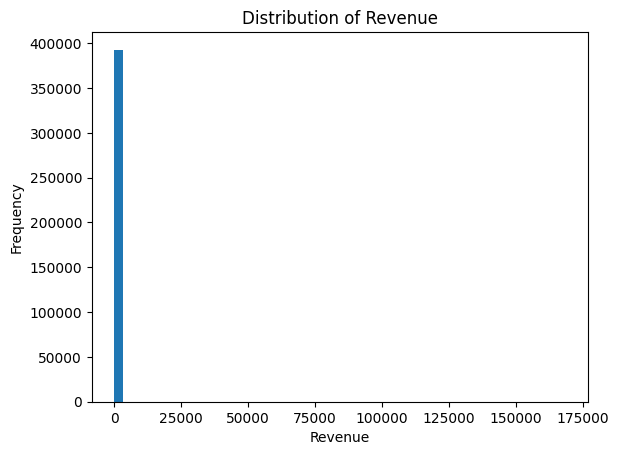

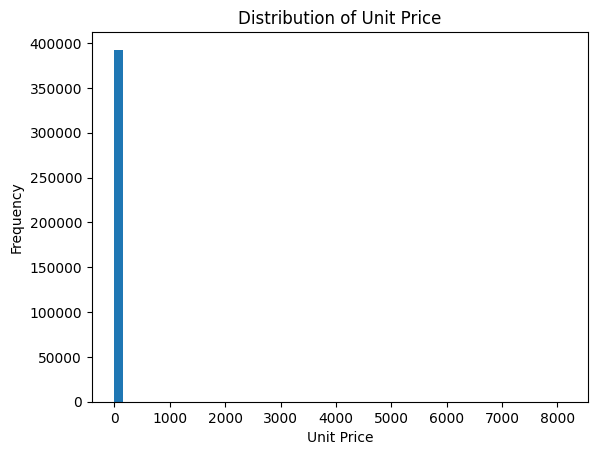

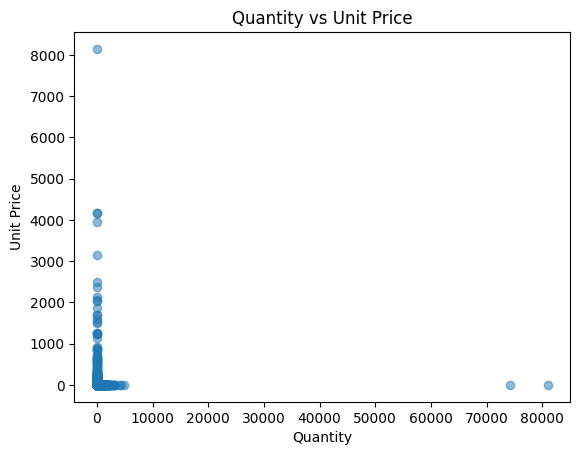

In [117]:
# visualize distribution

import matplotlib.pyplot as plt

# revenue distribution
df["Revenue"].plot(kind="hist", bins=50)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Distribution of Revenue")
plt.show()


#unitprice distribution
df["UnitPrice"].plot(kind="hist", bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price")
plt.show()

#checking if unusual system error between quantity and unitprice
plt.scatter(df["Quantity"], df["UnitPrice"], alpha=0.5)
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()




# Outlier Analysis Summary

- Both **Revenue** and **UnitPrice** exhibit a right-skewed distribution, with most transactions concentrated at lower values.
- The scatter plot shows that most transactions involve relatively low quantities and low unit prices.
- A small number of transactions contain either large quantities or higher-priced products, which is expected in retail environments.
- No obvious evidence of systematic data entry errors was identified from the transaction patterns.
- Since the detected outliers are likely to represent genuine business transactions, they were retained to preserve the integrity of the sales analysis.

In [118]:
display(df.sample(20))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeekday,InvoiceQuarter,InvoiceHour,InvoiceMonthName
221122,556239,23298,Spotty Bunting,6,2011-06-09 15:48:00,4.95,15712,United Kingdom,29.70,2011,6,9,Thursday,2,15,June
164690,550659,84991,60 Teatime Fairy Cake Cases,24,2011-04-20 09:02:00,0.55,17730,United Kingdom,13.20,2011,4,20,Wednesday,2,9,April
110935,545701,22293,Hanging Chick Green Decoration,7,2011-03-06 15:17:00,1.45,17107,United Kingdom,10.15,2011,3,6,Sunday,1,15,March
309032,564061,23133,Large Ivory Heart Wall Organiser,1,2011-08-22 14:38:00,8.25,14505,United Kingdom,8.25,2011,8,22,Monday,3,14,August
357113,568065,22767,Triple Photo Frame Cornice,2,2011-09-23 13:44:00,9.95,16240,United Kingdom,19.90,2011,9,23,Friday,3,13,September
424362,573264,23582,Vintage Doily Jumbo Bag Red,10,2011-10-28 12:36:00,2.08,14415,United Kingdom,20.80,2011,10,28,Friday,4,12,October
168481,551056,21754,Home Building Block Word,1,2011-04-26 11:51:00,5.95,16442,United Kingdom,5.95,2011,4,26,Tuesday,2,11,April
321806,565204,47504K,English Rose Garden Secateurs,24,2011-09-01 16:45:00,0.79,15829,United Kingdom,18.96,2011,9,1,Thursday,3,16,September
418615,572735,23493,Vintage Doily Travel Sewing Kit,10,2011-10-25 15:36:00,1.95,15630,United Kingdom,19.50,2011,10,25,Tuesday,4,15,October
261520,559866,85130D,Beaded Crystal Heart Pink Large,24,2011-07-13 10:43:00,0.79,15795,United Kingdom,18.96,2011,7,13,Wednesday,3,10,July


In [119]:
df.to_csv("Online_Retail_Cleaned.csv")
from google.colab import files
files.download("Online_Retail_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 Dashboard Design Plan

After successfully cleaning the Online Retail dataset and performing feature engineering, an interactive Streamlit dashboard was developed to present the most important business insights in a simple and user-friendly way.

### Dashboard Components

- **Sidebar Filters**
  - Year
  - Quarter
  - Country

- **Key Performance Indicators (KPIs)**
  - 💰 Total Revenue
  - 📦 Products Sold
  - 🛒 Total Orders
  - 🏷️ Total Products

- **Interactive Charts**
  - Revenue by Weekday and Hour (Heatmap)
  - Product Revenue by Country (Treemap)
  - Revenue by Year and Quarter
  - Revenue by Month
  - Customer Purchase Frequency
  - Top 10 Products by Revenue

The dashboard allows users to explore the retail dataset interactively by selecting different filter values. All KPIs and visualizations update automatically based on the selected filters, making it easier to analyze sales performance and customer behavior.

In [120]:
#!pip install streamlit pyngrok

In [121]:
%%writefile app.py

import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(
    page_title="Online Retail Analysis",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded")

# Load the cleaned retail dataset
df = pd.read_csv("Online_Retail_Cleaned.csv")

# ---------------- SIDEBAR ----------------

st.logo("clipart2179733.png")
st.sidebar.title("🎛️ Filter Options")

selected_year = st.sidebar.selectbox(label="📅 Select Year", options=df["InvoiceYear"].unique())

selected_quarter = st.sidebar.selectbox(label="📊 Select Quarter",options=df["InvoiceQuarter"].unique())

selected_country = st.sidebar.selectbox(label="🌍 Select Country",options=df["Country"].unique())

# Apply filters
filtered_df = df[(df["InvoiceYear"] == selected_year)
    & (df["InvoiceQuarter"] == selected_quarter)
    & (df["Country"] == selected_country)]

# ---------------- CHARTS ----------------

# Chart 1: Revenue by year and quarter
revenue_year_quarter = filtered_df.groupby(["InvoiceYear", "InvoiceQuarter"])["Revenue"].sum().reset_index()

fig1 = px.bar(
    revenue_year_quarter,
    x="InvoiceQuarter",
    y="Revenue",
    color="InvoiceYear",
    barmode="group",
    title="Revenue by Year and Quarter")

# Chart 2: Revenue by month
revenue_month = filtered_df.groupby("InvoiceMonth")["Revenue"].sum().reset_index()


fig2 = px.bar(
    revenue_month,
    x="InvoiceMonth",
    y="Revenue",
    title="Revenue by Month")

# Chart 3: Revenue by weekday and hour
revenue_day_hour = pd.pivot_table(
    filtered_df,
    index="InvoiceWeekday",
    columns="InvoiceHour",
    values="Revenue",
    aggfunc="sum")

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday", "Saturday","Sunday"]

revenue_day_hour = revenue_day_hour.reindex(weekday_order)

fig3 = px.imshow(
    revenue_day_hour,
    labels={"x": "Hour","y": "Weekday","color": "Revenue"},
    title="Revenue by Weekday and Hour",
    aspect="auto")

# Chart 4: Product revenue by country
product_revenue_country = filtered_df.groupby(["Country", "Description"])["Revenue"].sum().reset_index()

fig4 = px.treemap(
    product_revenue_country,
    path=["Country", "Description"],
    values="Revenue",
    title="Product Revenue by Country")

# Chart 5: Customer purchase frequency
customer_frequency = filtered_df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index(name="Orders")

purchase_frequency = (
    customer_frequency.groupby("Orders")["CustomerID"]
    .count()
    .reset_index(name="Customers"))

fig5 = px.bar(
    purchase_frequency,
    x="Orders",
    y="Customers",
    title="Customer Purchase Frequency")

# Chart 6: Top products by revenue
top_products = filtered_df.groupby("Description")["Revenue"].sum().reset_index().sort_values("Revenue", ascending=False).head(10)

fig6 = px.bar(
    top_products,
    x="Revenue",
    y="Description",
    orientation="h",
    title="Top 10 Products by Revenue")

# ---------------- TITLE ----------------

st.title("🛍️ Retail Sales Dashboard")
st.caption("Interactive Overview of Retail Sales Performance")

# ---------------- KPIs ----------------

info1, info2, info3, info4 = st.columns(4)

with info1:
    st.metric(
        label="💰 Total Revenue",
        value=f"${filtered_df['Revenue'].sum():,.2f}",
        border=True)

with info2:
    st.metric(
        label="📦 Products Sold",
        value=f"{filtered_df['Quantity'].sum():,}",
        border=True)

with info3:
    st.metric(
        label="🛒 Total Orders",
        value=f"{filtered_df['InvoiceNo'].nunique():,}",
        border=True)

with info4:
    st.metric(
        label="🏷️ Total Products",
        value=f"{filtered_df['Description'].nunique():,}",
        border=True)

st.divider()


# charts

chart1, chart2 = st.columns(2)

with chart1:
    st.plotly_chart(fig3, width="stretch")

with chart2:
    st.plotly_chart(fig4, width="stretch")

st.divider()


chart3, chart4, chart5, chart6 = st.columns(4)

with chart3:
    st.plotly_chart(fig1, width="stretch")

with chart4:
    st.plotly_chart(fig2, width="stretch")

with chart5:
    st.plotly_chart(fig5, width="stretch")

with chart6:
    st.plotly_chart(fig6, width="stretch")


Overwriting app.py


In [122]:
!streamlit run app.py --server.port 8501 &



2026-07-14 14:02:45.129 Port 8501 is not available


In [123]:
!cat /content/logs.txt



2026-07-14 13:17:47.770 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.81.87.70:8501



In [124]:
from pyngrok import ngrok
ngrok.kill()
ngrok.set_auth_token("3GUbEO5ZUSUtRNG8vC2ZJ2Yrqpu_2dTW5SozU8Ltyna6nhRWw")
public_url = ngrok.connect(8501)

print(public_url.public_url)


https://copious-overrate-had.ngrok-free.dev


# 🚀 Deploying the Streamlit Dashboard with Ngrok

To make the dashboard accessible through a web browser, **Ngrok** was used to create a secure public URL for the Streamlit application.

### Steps

1. Create an Ngrok account and obtain a personal authentication token.
2. Write the Streamlit application inside an `app.py` file using:


%%writefile app.py


3. Start the Streamlit server:


!streamlit run app.py --server.port 8501 &


4. Verify that the server is running successfully by checking the log file:


!cat /content/logs.txt


This confirms that the Streamlit application is running without errors.

5. Authenticate Ngrok and create a public URL:


from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token()

public_url = ngrok.connect(8501)

print(public_url.public_url)


The generated URL can be opened in any web browser to access the interactive dashboard from anywhere.

#📌 Conclusion

This project combined data cleaning, feature engineering, data visualization, and dashboard development into one complete workflow. Using Pandas, Plotly, and Streamlit, an interactive dashboard was created to explore retail sales data through filters, KPIs, and dynamic visualizations. This project strengthened my understanding of the end-to-end data analysis process and demonstrated how Python can be used to build practical, interactive business dashboards.